# EDA – FitLife Health & Fitness Tracking Dataset

Ce notebook explore le dataset **FitLife Health & Fitness Tracking** dans le cadre du projet TrAIn.me.

L’objectif est de vérifier la qualité des données (structure, typage, complétude) avant toute
modélisation prédictive.

## Objectif

Vérifier que le fichier `health_fitness_dataset.csv` est correctement chargé et obtenir une vue
d’ensemble :

- dimensions du jeu de données (nombre de lignes et de colonnes) ;
- typage des variables (numériques, catégorielles) ;
- première inspection des valeurs manquantes et des doublons ;
- cohérence générale du corpus avant analyse statistique détaillée.

## Interprétation attendue

À partir de cette première inspection, il s’agira de commenter :

- la taille globale du dataset (nombre de lignes / colonnes) ;
- la nature des variables (mélange de mesures numériques, indicateurs de santé et catégories) ;
- la présence éventuelle de valeurs manquantes et leur concentration sur certaines colonnes ;
- l’existence (ou non) de doublons dans les données brutes ;
- la cohérence générale des premières lignes (valeurs réalistes, formats attendus).

Cette interprétation sert de point de départ pour juger de la qualité du corpus et décider des
premières actions de nettoyage à mener dans les sections suivantes.


## Configuration notebook

### Importation des librairies essentielles

In [44]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import prince

from pathlib import Path
import sys

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats

# === Localiser automatiquement le package 'themes' en remontant l'arborescence ===
root = Path.cwd()  # ex : .../train.me/src/notebooks/eda/health_fitness_dataset
themes_root = None

for p in [root, *root.parents]:
    if (p / "themes").is_dir():
        themes_root = p
        break

if themes_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier 'themes' en partant de {root}. "
        "Vérifie l'arborescence : il doit exister un dossier 'themes/' quelque part au-dessus."
    )

if str(themes_root) not in sys.path:
    sys.path.insert(0, str(themes_root))

print("✅ Ajouté au PYTHONPATH :", themes_root)
print("📂 Contenu de", themes_root, ":", [x.name for x in themes_root.iterdir()])

from themes.theme_train_me import set_trainme_theme

✅ Ajouté au PYTHONPATH : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks
📂 Contenu de c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks : ['eda', 'model_training', 'preprocessing', 'themes', '__init__.py']


#### Configuration d’affichage et thème TrAIn.me


In [2]:
# Options d’affichage pour les tableaux
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# =============================
# Thème TrAIn.me (Seaborn/Matplotlib)
# =============================
USE_DARK_THEME = True  # bascule possible vers un thème clair si besoin

palette_trainme = set_trainme_theme(
    context="talk",
    font_scale=1.05,
    use_dark=USE_DARK_THEME
)

palette_trainme


['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']

### Activation du thème TrAIn.me

In [3]:
if USE_DARK_THEME:
    palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
else:
    sns.set_style("ticks")              # style clair sobre, axes renforcés
    sns.set_context("talk", font_scale=1.05)
    palette_trainme = sns.color_palette("deep")  # palette par défaut sobre
    print("🎨 Style activé : 'ticks' → sobre, axes renforcés (présentation pro)")

# Exemple de vérification :
print("Palette active :", palette_trainme.as_hex() if hasattr(palette_trainme, "as_hex") else palette_trainme)


Palette active : ['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']


## Chargement et inspection initiale

#### Chargement du dataset `health_fitness_dataset.csv`


In [4]:
# Téléchargement du dataset depuis Kaggle
dataset_path = kagglehub.dataset_download("jijagallery/fitlife-health-and-fitness-tracking-dataset")

# Recherche du fichier CSV dans le dossier téléchargé
csv_files = [f for f in os.listdir(dataset_path) if f.endswith(".csv")]
print("Fichiers trouvés :", csv_files)

# Construction du chemin complet vers le CSV
file_path = os.path.join(dataset_path, csv_files[0])


# Lecture du fichier CSV
df = pd.read_csv(file_path)

# Informations de confirmation
print("Dataset chargé avec succès !")
print(f"Dimensions : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")


Fichiers trouvés : ['health_fitness_dataset.csv']
Dataset chargé avec succès !
Dimensions : 687701 lignes et 22 colonnes



#### Aperçu des premières lignes


In [5]:
df.head(10)


,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,103,6.6,3,7128,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,102,8.1,7,7925,1.8,19.6,69.5,110.7,72.9,NaN,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,126,6.2,7,7557,2.7,19.6,69.5,110.7,72.9,NaN,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,141,7.2,8,11120,2.6,19.6,69.5,110.7,72.9,NaN,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,112,7.1,1,5406,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.33
5,1,2024-01-10,56,F,165.3,54.9,HIIT,31,Medium,6.8,121,7.5,10,10202,2.2,19.6,69.5,110.7,72.9,NaN,Never,0.37
6,1,2024-01-11,56,F,165.3,55.2,Weight Training,97,High,12.4,145,6.6,8,5912,2.8,19.6,69.5,110.7,72.9,NaN,Never,0.51
7,1,2024-01-12,56,F,165.3,55.5,HIIT,70,Low,12.9,99,6.1,7,9477,1.6,19.6,69.5,110.7,72.9,NaN,Never,0.58
8,1,2024-01-17,56,F,165.3,55.7,HIIT,89,Medium,19.7,112,7.2,7,9710,3.3,19.6,69.5,110.7,72.9,NaN,Never,0.68
9,1,2024-01-18,56,F,165.3,56.0,Weight Training,115,Medium,12.8,117,5.6,3,7830,2.0,19.6,69.5,110.7,72.9,NaN,Never,0.82


#### Informations sur le typage, les valeurs manquantes et les doublons


In [6]:
# Typage et complétude globale
df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   participant_id            687701 non-null  int64  
 1   date                      687701 non-null  object 
 2   age                       687701 non-null  int64  
 3   gender                    687701 non-null  object 
 4   height_cm                 687701 non-null  float64
 5   weight_kg                 687701 non-null  float64
 6   activity_type             687701 non-null  object 
 7   duration_minutes          687701 non-null  int64  
 8   intensity                 687701 non-null  object 
 9   calories_burned           687701 non-null  float64
 10  avg_heart_rate            687701 non-null  int64  
 11  hours_sleep               687701 non-null  float64
 12  stress_level              687701 non-null  int64  
 13  daily_steps               687701 non-null  i

### Statistiques descriptives des variables numériques

In [7]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
participant_id,687701.0,1499.781828,865.997215,1.00,749.00,1499.00,2249.00,3000.00
age,687701.0,41.658602,13.581770,18.00,30.00,42.00,53.00,64.00
height_cm,687701.0,168.587699,9.140811,145.00,161.70,168.20,175.30,198.50
weight_kg,687701.0,94.921981,22.461801,45.30,78.20,94.60,110.50,188.40
duration_minutes,687701.0,70.011671,29.147251,20.00,45.00,70.00,95.00,120.00
calories_burned,687701.0,15.381302,9.985552,0.80,7.80,13.00,20.70,92.00
avg_heart_rate,687701.0,131.454165,17.814744,82.00,118.00,130.00,144.00,206.00
hours_sleep,687701.0,7.048799,0.972068,4.00,6.40,7.00,7.70,10.00
stress_level,687701.0,5.252389,2.770029,1.00,3.00,5.00,8.00,10.00
daily_steps,687701.0,8628.370918,2054.756608,-419.00,7203.00,8607.00,10027.00,17241.00


### Analyse des valeurs manquantes et doublons

In [8]:
# Comptage des valeurs manquantes par colonne
missing_counts = df.isna().sum().sort_values(ascending=False)

print("\n🔎 Valeurs manquantes par colonne (top 20) :")
display(missing_counts.head(20))

# Comptage des doublons ligne à ligne
n_duplicates = df.duplicated().sum()
print(f"\n🧬 Nombre de doublons (lignes strictement identiques) : {n_duplicates}")


🔎 Valeurs manquantes par colonne (top 20) :


health_condition            490275
participant_id                   0
date                             0
smoking_status                   0
blood_pressure_diastolic         0
blood_pressure_systolic          0
resting_heart_rate               0
bmi                              0
hydration_level                  0
daily_steps                      0
stress_level                     0
hours_sleep                      0
avg_heart_rate                   0
calories_burned                  0
intensity                        0
duration_minutes                 0
activity_type                    0
weight_kg                        0
height_cm                        0
gender                           0
dtype: int64


🧬 Nombre de doublons (lignes strictement identiques) : 0


### Liste complète des colonnes disponibles

In [9]:
print("\n--- Liste des colonnes du dataset ---")
print(df.columns.tolist())


--- Liste des colonnes du dataset ---
['participant_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg', 'activity_type', 'duration_minutes', 'intensity', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'health_condition', 'smoking_status', 'fitness_level']


## Statistiques descriptives et distribution des variables

### Objectif

Obtenir une vue d’ensemble chiffrée des variables du dataset :

- résumer la distribution des variables numériques (moyenne, médiane, min, max, quartiles) ;
- analyser la répartition des variables catégorielles (genres, types d’activités, intensité, etc.) ;
- repérer les ordres de grandeur, les asymétries et les éventuelles valeurs extrêmes ;
- préparer l’identification de patterns intéressants pour la modélisation.

### Interprétation attendue

À l’issue de cette étape, l’interprétation devra mettre en évidence :

- les valeurs centrales des variables clés (moyennes, médianes, étendue) pour caractériser le profil général des participants ;
- la dispersion et la variabilité des mesures (écarts-types, quartiles), permettant d’identifier des comportements hétérogènes ou des tendances majoritaires ;
- la présence éventuelle de valeurs extrêmes ou atypiques (poids très élevé, steps négatifs, calories inhabituellement hautes) qui pourront nécessiter un traitement spécifique ;
- la répartition des modalités des variables catégorielles (genre, types d’activités, intensité), révélant les comportements majoritaires ;
- les premières pistes d’analyse quant aux relations possibles entre activité physique, niveaux de stress, sommeil, hydratation et condition physique.

Cette interprétation servira de base pour orienter la suite de l’analyse, notamment l’identification des corrélations, la détection d’anomalies et la préparation des features pour la modélisation prédictive.


### Statistiques descriptives globales


In [10]:
# Statistiques descriptives de base
stats = df.describe().T
display(stats)

# Vérification des bornes extrêmes sur les principales métriques du dataset FitLife
print(f"Âge moyen : {df['age'].mean():.1f} ans")
print(f"Poids moyen : {df['weight_kg'].mean():.1f} kg")
print(f"Calories moyennes brûlées : {df['calories_burned'].mean():.0f} kcal")
print(f"IMC moyen : {df['bmi'].mean():.1f}")


,count,mean,std,min,25%,50%,75%,max
participant_id,687701.0,1499.781828,865.997215,1.00,749.00,1499.00,2249.00,3000.00
age,687701.0,41.658602,13.581770,18.00,30.00,42.00,53.00,64.00
height_cm,687701.0,168.587699,9.140811,145.00,161.70,168.20,175.30,198.50
weight_kg,687701.0,94.921981,22.461801,45.30,78.20,94.60,110.50,188.40
duration_minutes,687701.0,70.011671,29.147251,20.00,45.00,70.00,95.00,120.00
calories_burned,687701.0,15.381302,9.985552,0.80,7.80,13.00,20.70,92.00
avg_heart_rate,687701.0,131.454165,17.814744,82.00,118.00,130.00,144.00,206.00
hours_sleep,687701.0,7.048799,0.972068,4.00,6.40,7.00,7.70,10.00
stress_level,687701.0,5.252389,2.770029,1.00,3.00,5.00,8.00,10.00
daily_steps,687701.0,8628.370918,2054.756608,-419.00,7203.00,8607.00,10027.00,17241.00


Âge moyen : 41.7 ans
Poids moyen : 94.9 kg
Calories moyennes brûlées : 15 kcal
IMC moyen : 22.7


### Distribution des variables clés


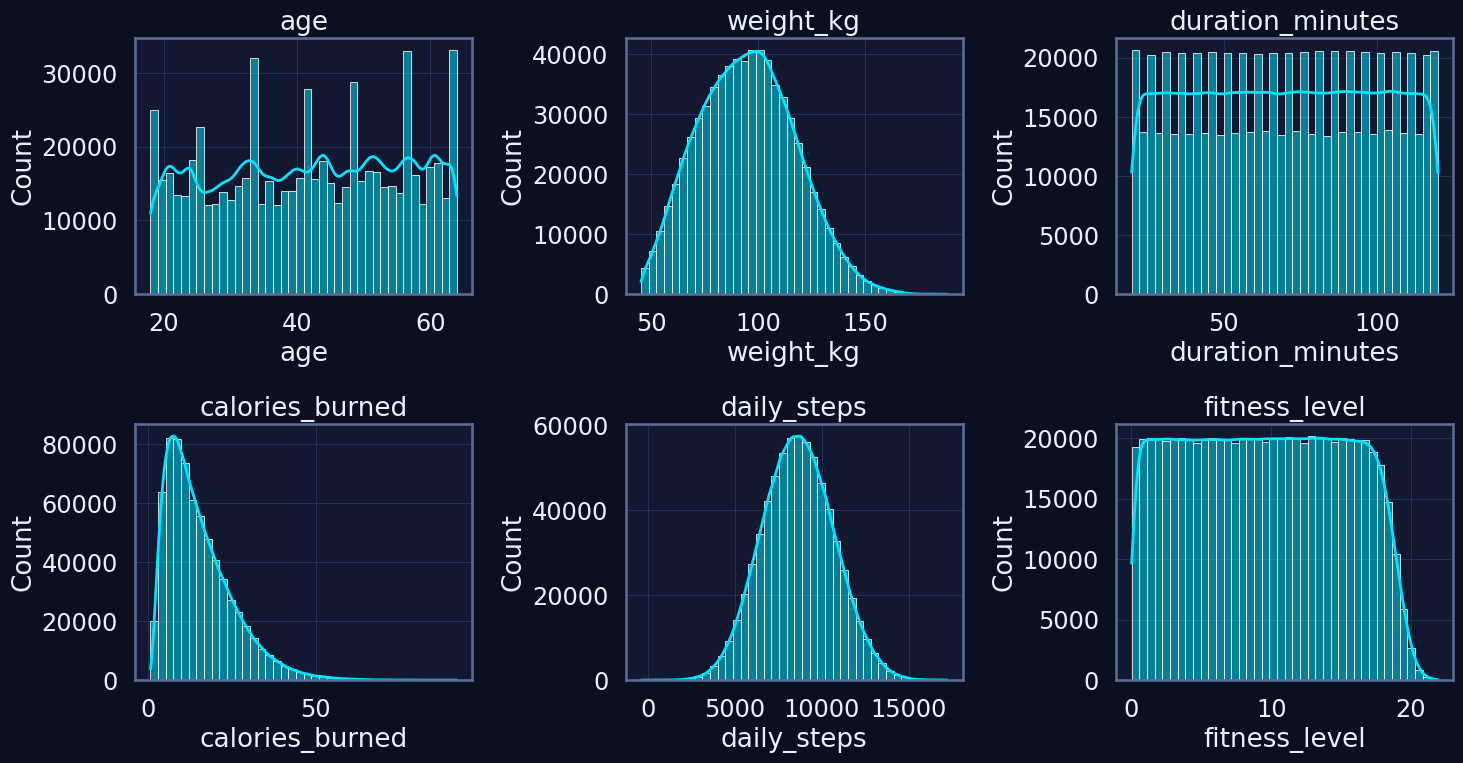

In [11]:
num_vars = [
    "age",
    "weight_kg",
    "duration_minutes",
    "calories_burned",
    "daily_steps",
    "fitness_level"
]

num_vars = [v for v in num_vars if v in df.columns]

n = len(num_vars)
n_cols = 3
n_rows = int(np.ceil(n / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(num_vars, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(col)
    plt.grid(True)

plt.tight_layout()
plt.show()


### Boxplots pour repérer les outliers


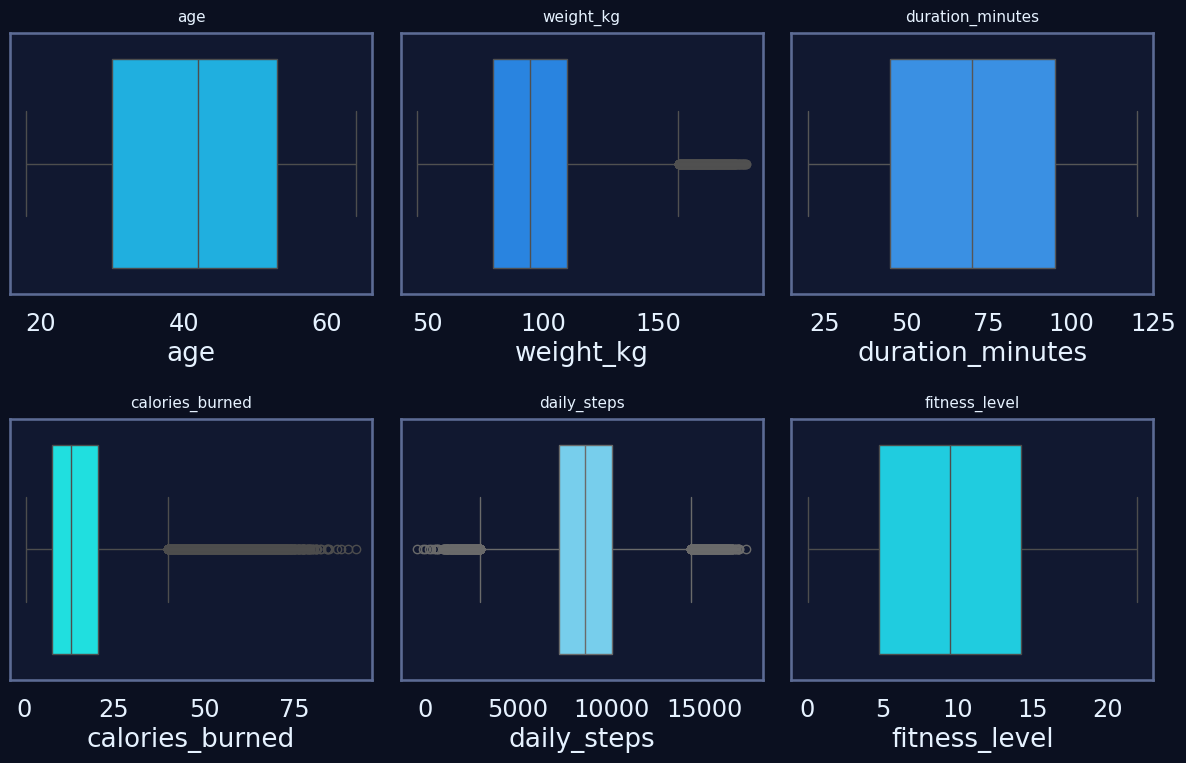

In [12]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_vars, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color=palette_trainme[i % len(palette_trainme)])
    plt.title(col, fontsize=11, pad=8)
plt.tight_layout()
plt.show()


### Statistiques descriptives enrichies


In [13]:
# --- Colonnes numériques (on exclut les colonnes dérivées à magnitude extrême) ---
num_cols = df.select_dtypes(include="number").columns.tolist()
to_exclude = ["Burns Calories (per 30 min)_bc"]  # valeurs ~1e19–1e20, non comparables
num_cols = [c for c in num_cols if c not in to_exclude]

print(f"{len(num_cols)} variables numériques analysées.")

desc = df[num_cols].describe().T
desc["missing_%"] = df[num_cols].isna().mean() * 100
desc["zeros_%"]   = (df[num_cols] == 0).mean() * 100
desc["skew"]      = df[num_cols].skew()
desc["kurt"]      = df[num_cols].kurt()

display(desc.sort_values("std", ascending=False).head(12))  # top 12 par variance


16 variables numériques analysées.


,count,mean,std,min,25%,50%,75%,max,missing_%,zeros_%,skew,kurt
daily_steps,687701.0,8628.370918,2054.756608,-419.00,7203.00,8607.00,10027.00,17241.00,0.0,0.0,0.062185,-0.155186
participant_id,687701.0,1499.781828,865.997215,1.00,749.00,1499.00,2249.00,3000.00,0.0,0.0,0.000852,-1.200757
duration_minutes,687701.0,70.011671,29.147251,20.00,45.00,70.00,95.00,120.00,0.0,0.0,-0.001944,-1.199195
weight_kg,687701.0,94.921981,22.461801,45.30,78.20,94.60,110.50,188.40,0.0,0.0,0.191474,-0.378706
avg_heart_rate,687701.0,131.454165,17.814744,82.00,118.00,130.00,144.00,206.00,0.0,0.0,0.360952,-0.234441
age,687701.0,41.658602,13.581770,18.00,30.00,42.00,53.00,64.00,0.0,0.0,-0.063646,-1.193656
blood_pressure_systolic,687701.0,120.001260,10.008917,78.00,113.10,120.20,127.00,152.70,0.0,0.0,-0.072306,0.008349
calories_burned,687701.0,15.381302,9.985552,0.80,7.80,13.00,20.70,92.00,0.0,0.0,1.235929,1.891749
height_cm,687701.0,168.587699,9.140811,145.00,161.70,168.20,175.30,198.50,0.0,0.0,0.179715,-0.435383
blood_pressure_diastolic,687701.0,80.188079,8.239418,53.70,74.60,80.10,85.70,112.10,0.0,0.0,0.132936,0.078316


### Détection rapide d’outliers (IQR)


In [14]:
iqr_report = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    iqr_report[col] = len(outliers)

iqr_df = pd.DataFrame.from_dict(iqr_report, orient="index", columns=["outliers"])
iqr_df.sort_values("outliers", ascending=False).head(15)


,outliers
calories_burned,17441
blood_pressure_diastolic,6107
hours_sleep,5897
bmi,4147
resting_heart_rate,3738
blood_pressure_systolic,3602
daily_steps,3094
avg_heart_rate,1867
weight_kg,1706
height_cm,460


### Aperçu corrélations (sous-ensemble lisible)


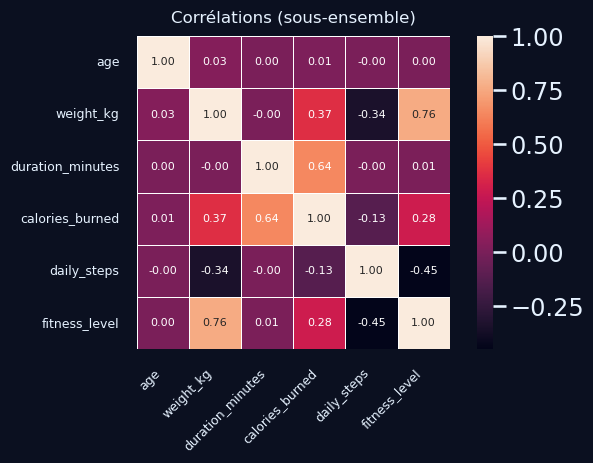

In [15]:
subset_cols = ["age", "weight_kg", "duration_minutes", "calories_burned", "daily_steps", "fitness_level"]
corr = df[subset_cols].corr(numeric_only=True)
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=True,
    cbar=True,
    annot_kws={"size": 8},    # 🔹 taille des annotations
    linewidths=0.5,           # optionnel : lignes fines entre les cases
)

plt.title("Corrélations (sous-ensemble)", fontsize=12, pad=10)
plt.xticks(fontsize=9, rotation=45, ha="right")
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()


## Visualisation univariée

### Objectif

L’objectif de cette section est de compléter les statistiques descriptives par une analyse
visuelle des distributions :

- observer la forme des distributions (symétrie, asymétrie, aplatissement) ;
- repérer les valeurs extrêmes ou atypiques visibles sur les graphiques ;
- identifier les variables présentant des comportements particuliers (effet de seuil, plafond, etc.) ;
- préparer les décisions de nettoyage et de transformation (normalisation, winsorisation, log-scale…).


### Interprétation attendue

À l’issue de cette étape, l’interprétation devra :

- décrire les grandes tendances des distributions (centrées, étalées, asymétriques, multimodales) ;
- signaler les variables possédant des queues longues ou des concentrations de valeurs extrêmes ;
- distinguer les variables “propres” (distributions régulières) des variables nécessitant un traitement
  spécifique avant la modélisation ;
- mettre en évidence les variables les plus informatives pour caractériser les profils utilisateurs
  (ex. durée des séances, nombre de pas, niveau de forme, stress, sommeil).

Ces éléments guideront la stratégie de nettoyage et de préparation des features.


### Visualisation des distributions univariées


Variables numériques visualisées (15) : ['age', 'height_cm', 'weight_kg', 'duration_minutes', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fitness_level']


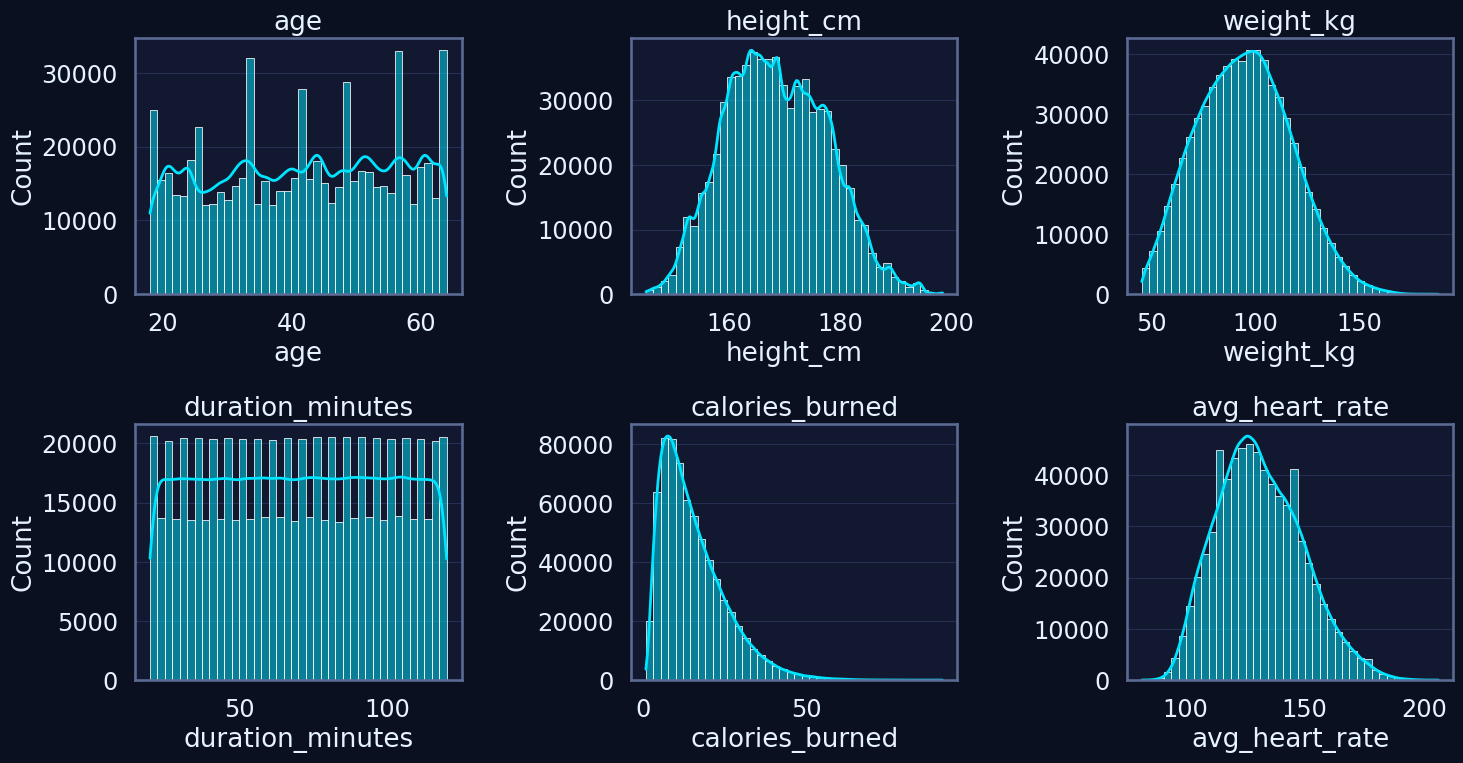

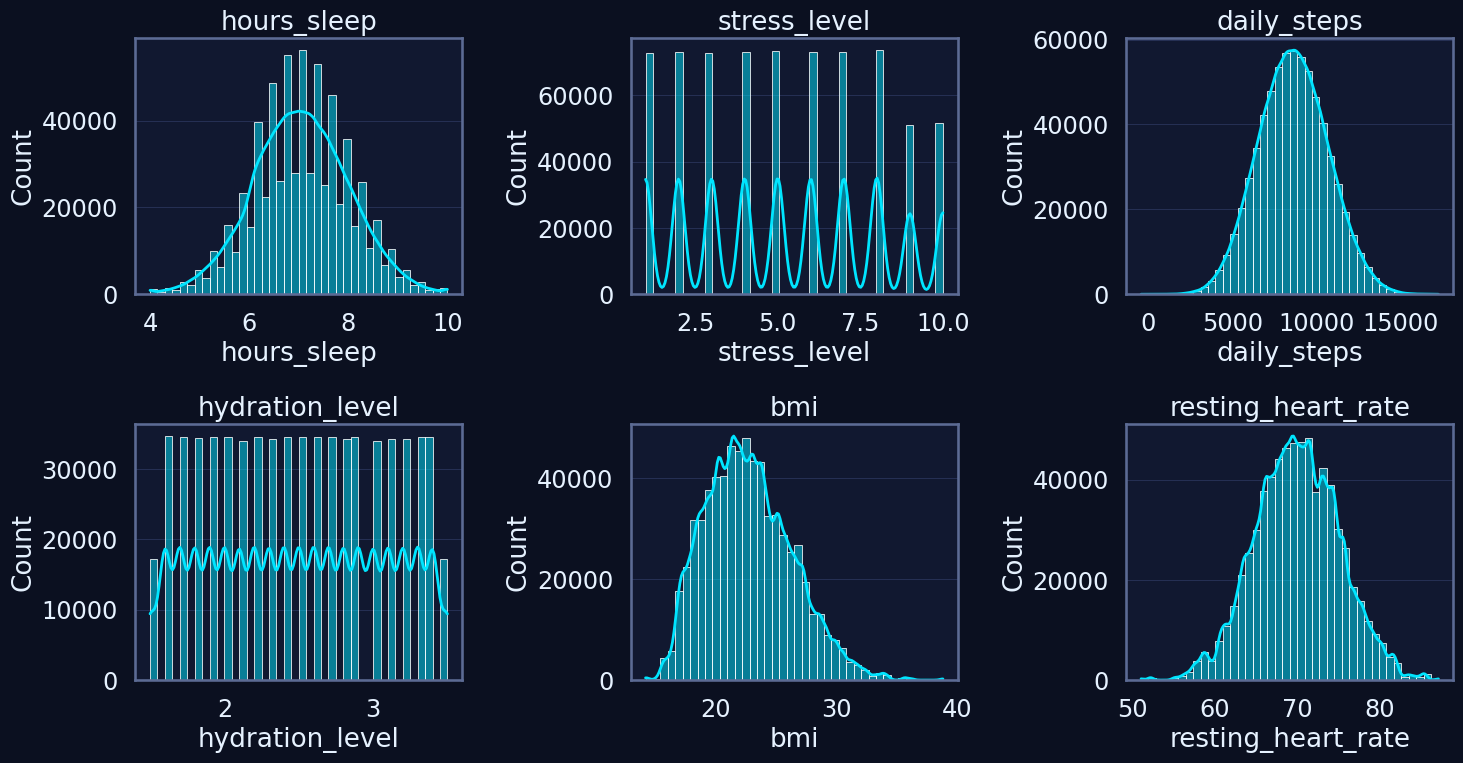

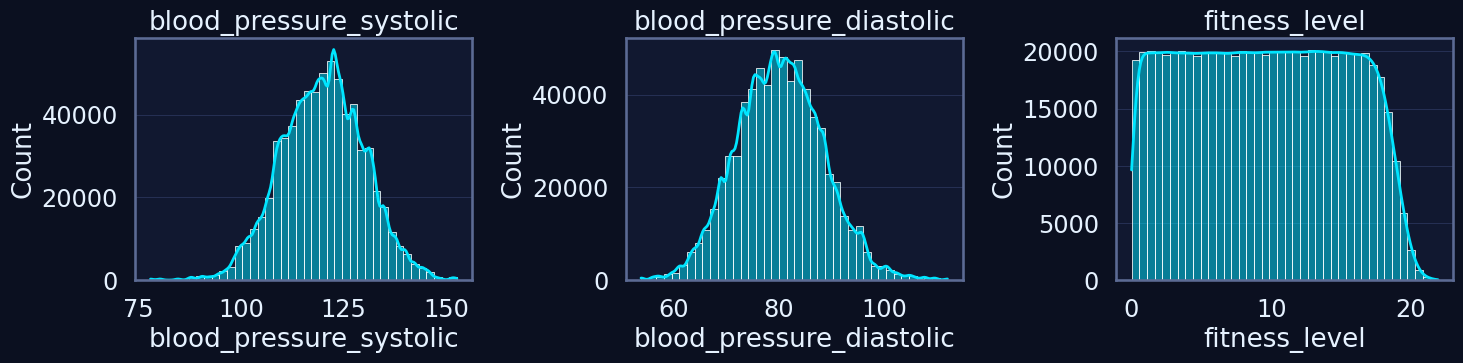

In [16]:
# Sélection des variables numériques à visualiser
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# On retire les identifiants techniques qui n'ont pas d'intérêt de distribution métier
cols_exclude = ["participant_id"]
num_to_plot = [c for c in num_cols if c not in cols_exclude]

print(f"Variables numériques visualisées ({len(num_to_plot)}) : {num_to_plot}")

# Affichage par paquets pour garder des figures lisibles
n_cols = 3
batch_size = n_cols * 2  # 2 lignes par figure

for i in range(0, len(num_to_plot), batch_size):
    batch = num_to_plot[i : i + batch_size]
    n = len(batch)
    n_rows = int(np.ceil(n / n_cols))

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for j, col in enumerate(batch, start=1):
        plt.subplot(n_rows, n_cols, j)
        sns.histplot(df[col], bins=40, kde=True)
        plt.title(col)
        plt.grid(True, axis="y")

    plt.tight_layout()
    plt.show()


### Boxplots univariés pour détection visuelle d'outliers


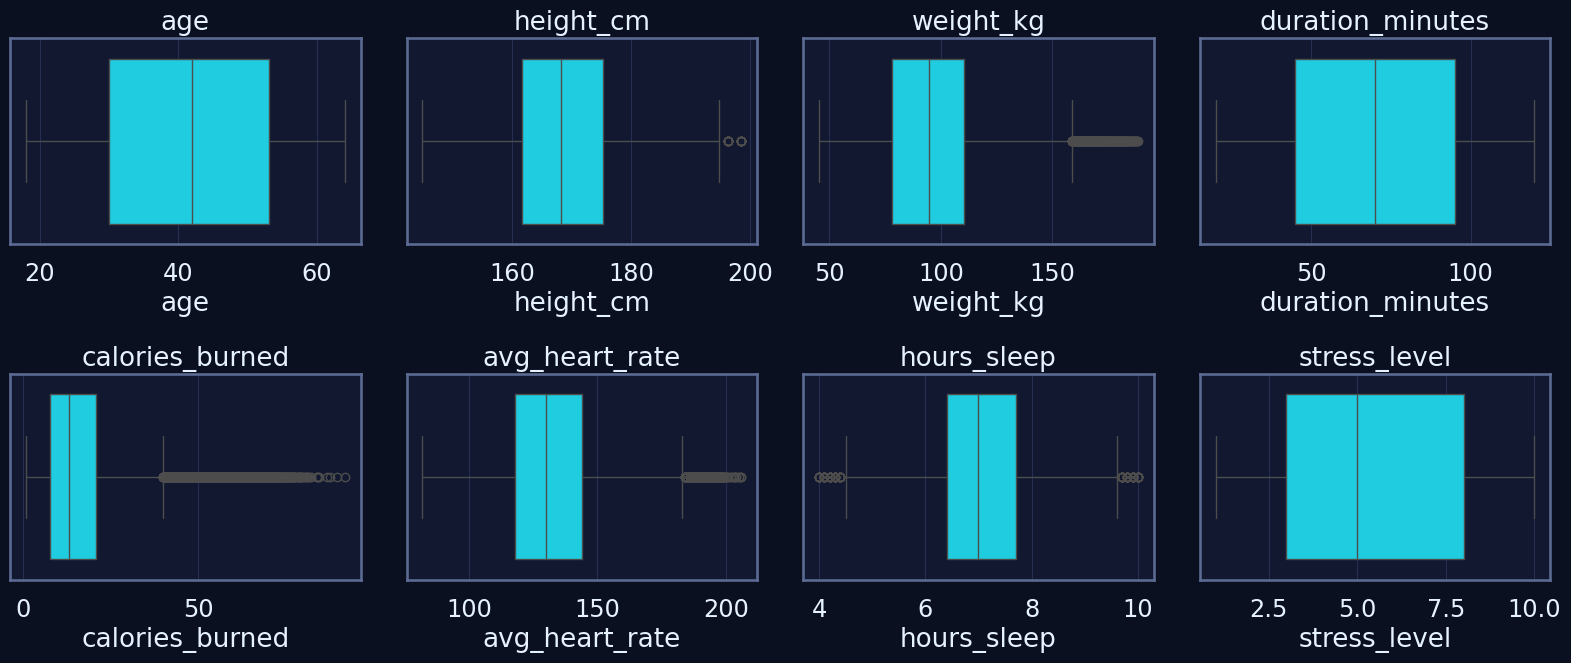

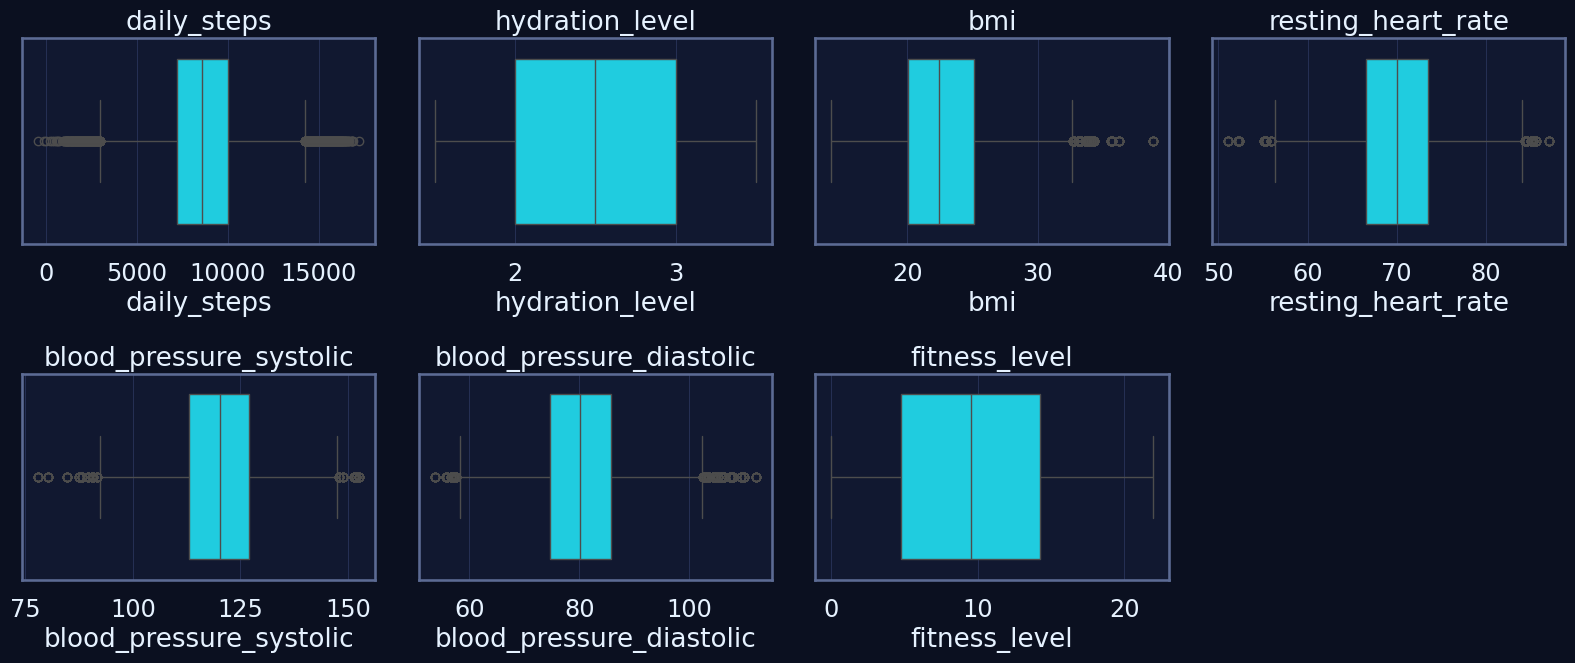

In [17]:
# Même sous-ensemble que pour les histogrammes
num_to_plot = [c for c in num_cols if c not in cols_exclude]

n_cols = 4
batch_size = n_cols * 2  # 2 lignes par figure

for i in range(0, len(num_to_plot), batch_size):
    batch = num_to_plot[i : i + batch_size]
    n = len(batch)
    n_rows = int(np.ceil(n / n_cols))

    plt.figure(figsize=(4 * n_cols, 3.5 * n_rows))

    for j, col in enumerate(batch, start=1):
        plt.subplot(n_rows, n_cols, j)
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.grid(True, axis="x")

    plt.tight_layout()
    plt.show()


## Visualisation bivariée


### Objectif

Étudier les relations entre deux variables à la fois afin d’identifier :

- des corrélations linéaires ou non linéaires entre indicateurs de santé et d’activité ;
- des patterns comportementaux (ex. durée de séance ↔ calories brûlées, sommeil ↔ niveau de stress) ;
- des dépendances entre variables physiologiques (IMC, fréquence cardiaque, pression artérielle) et niveau de forme globale.

Ces visualisations serviront de base pour repérer les couples de variables les plus pertinents pour la modélisation du projet TrAIn.me.


### Interprétation attendue

À l’issue de cette section, l’interprétation devra mettre en évidence :

- la relation entre **durée des séances**, **volume d’activité** (daily_steps) et **calories brûlées** ;
- l’influence de la **morphologie** (BMI, poids) sur la dépense énergétique ;
- les liens entre **sommeil**, **stress** et **fitness_level**, en particulier l’impact potentiel d’un bon sommeil sur la condition physique ;
- le rôle de l’**hydratation** comme facteur de performance (calories_burned, fitness_level) ;
- la présence éventuelle de comportements atypiques (profils très actifs mais peu en forme, ou inversement).

Ces observations guideront la suite de l’analyse multivariée et la sélection des features pour les futurs modèles prédictifs TrAIn.me.


### Relations physiologiques et comportementales

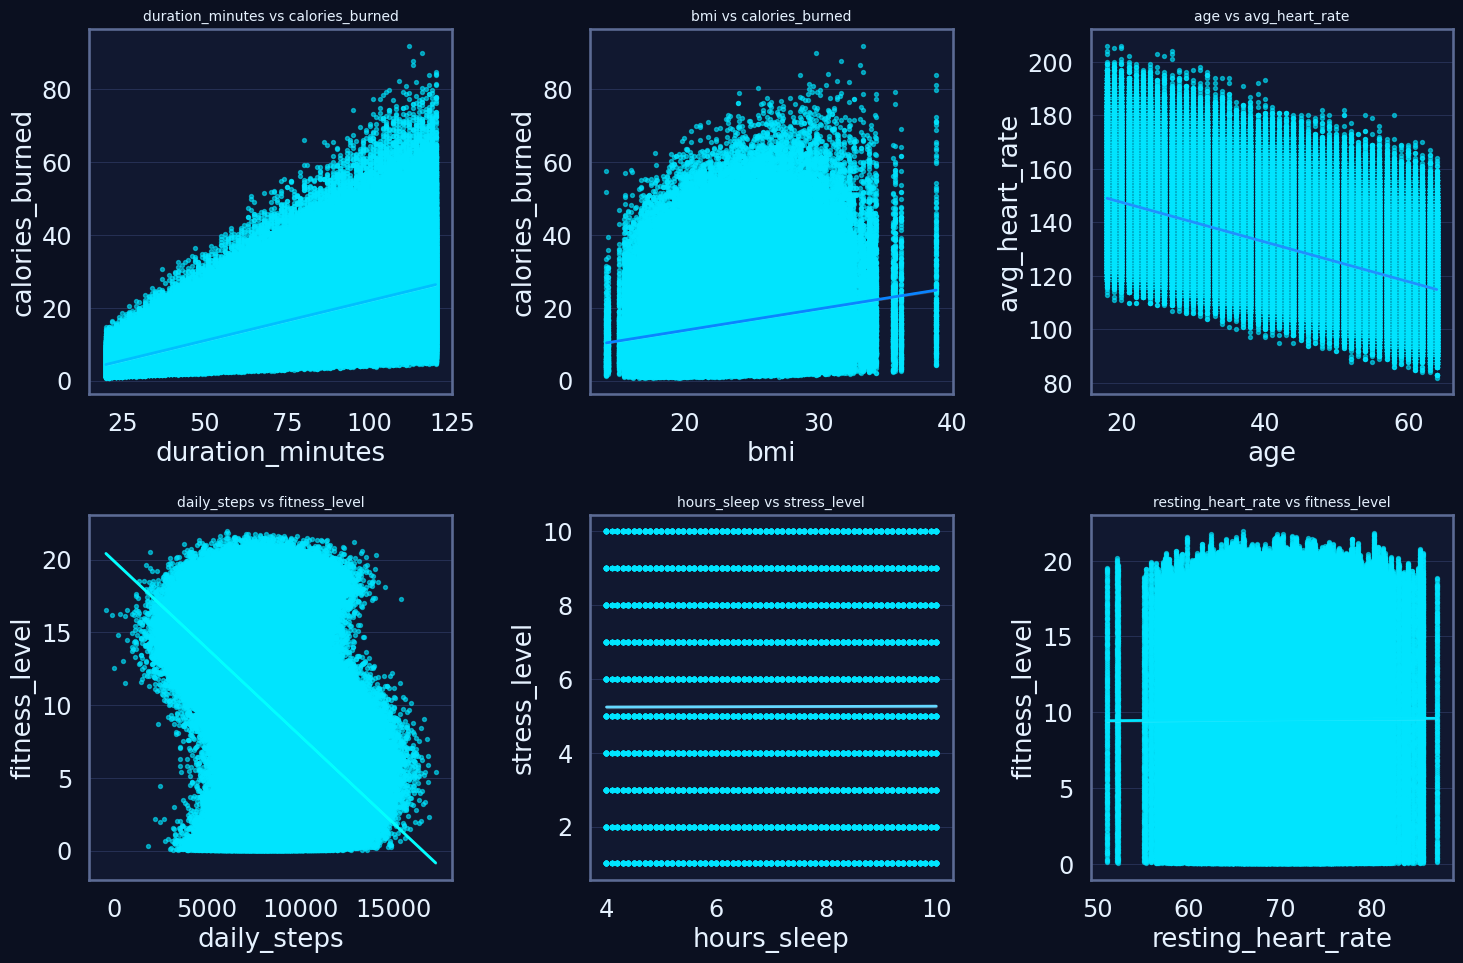

In [18]:
biv_pairs = [
    ("duration_minutes", "calories_burned"),
    ("bmi", "calories_burned"),
    ("age", "avg_heart_rate"),
    ("daily_steps", "fitness_level"),
    ("hours_sleep", "stress_level"),
    ("resting_heart_rate", "fitness_level"),
]

plt.figure(figsize=(15, 10))
for i, (x, y) in enumerate(biv_pairs, 1):
    ax = plt.subplot(2, 3, i)
    sns.regplot(
        data=df,
        x=x,
        y=y,
        scatter_kws={"s": 8, "alpha": 0.6},
        line_kws={
            "color": palette_trainme[i % len(palette_trainme)],
            "lw": 2,
        },
    )
    ax.set_title(f"{x} vs {y}", fontsize=10)
    ax.set_xlabel(x)
    ax.set_ylabel(y)

plt.tight_layout()
plt.show()


### Corrélation nutrition ↔ performance (hydratation & récupération)

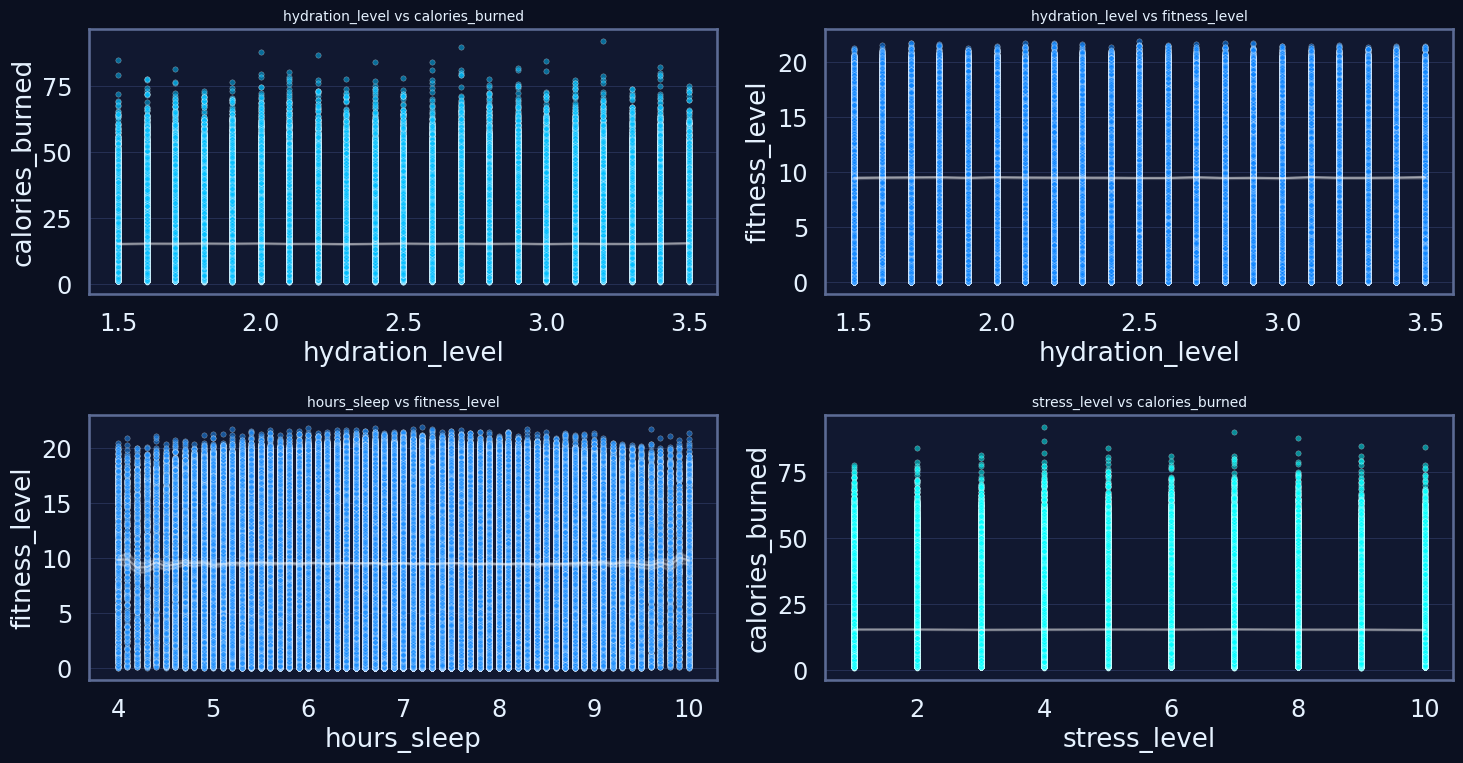

In [19]:
biv_pairs2 = [
    ("hydration_level", "calories_burned"),
    ("hydration_level", "fitness_level"),
    ("hours_sleep", "fitness_level"),
    ("stress_level", "calories_burned"),
]

plt.figure(figsize=(15, 8))
for i, (x, y) in enumerate(biv_pairs2, 1):
    ax = plt.subplot(2, 2, i)
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        color=palette_trainme[i % len(palette_trainme)],
        alpha=0.5,
        s=15,
    )
    sns.lineplot(
        data=df.sort_values(x),
        x=x,
        y=y,
        color="white",
        lw=1.5,
        alpha=0.4,
    )
    ax.set_title(f"{x} vs {y}", fontsize=10)
    ax.set_xlabel(x)
    ax.set_ylabel(y)

plt.tight_layout()
plt.show()


## Analyse multivariée (PCA - MCA – FAMD et FA  simplifiée)


### Objectif

Explorer la structure globale du dataset FitLife en combinant plusieurs approches multivariées.

L’objectif est de comprendre comment les variables numériques et catégorielles interagissent entre elles,
d’identifier des dimensions latentes expliquant les comportements d’activité, de santé et de mode de vie,
et de détecter d’éventuels regroupements de profils utilisateurs.

Pour cela, nous mobilisons trois méthodes complémentaires :
- PCA pour résumer l’information portée par les variables numériques (activité, physiologie, hygiène de vie).
- MCA pour analyser les relations entre les modalités des variables catégorielles (type d’activité, intensité, statut tabagique, conditions de santé).
- FAMD pour obtenir une vision intégrée des données mixtes et repérer les dimensions combinant simultanément indicateurs numériques et qualitatifs.

Ces analyses servent à guider la compréhension globale du dataset et orientent la sélection des features pour les modèles prédictifs TrAIn.me.


### Interprétation attendue

À l’issue de cette section, l’interprétation devra :
- préciser la part de variance expliquée par les premières dimensions (PCA, MCA, FAMD) et leur signification métier ;
- identifier les variables ou modalités les plus contributrices aux axes principaux :
par exemple, volume d’activité, intensité, fréquence cardiaque, sommeil, stress, hydratation, type d’activité ou statut tabagique ;
- repérer d’éventuels clusters naturels ou groupes cohérents dans les projections 2D (profils sportifs, profils sédentaires, profils “stressés”, profils “réguliers”, etc.) ;
- mettre en lumière les dimensions latentes qui structurent le dataset, telles que :
- activité / engagement sportif,
- équilibre santé / récupération,
- mode de vie / hygiène,
- charge cardiovasculaire,
- fournir une lecture métier des axes factoriels permettant de mieux comprendre les comportements observés, de préparer la segmentation des utilisateurs et d’orienter la sélection de variables.

Ces éléments constituent la base analytique permettant de passer ensuite à la modélisation supervisée ou à la création de profils personnalisés dans TrAIn.me.


### PCA (Principal Component Analysis)

L’objectif de cette analyse est d’explorer la structure des variables numériques du dataset FitLife
et d’identifier les dimensions sous-jacentes (composantes principales) expliquant la majorité de la variance.


#### Sélection & scaling des variables numériques

In [21]:
# Sélection des variables numériques
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# On exclut les identifiants techniques
cols_exclude = ["participant_id"]
num_pca_cols = [c for c in num_cols if c not in cols_exclude]

print(f"Variables retenues pour la PCA ({len(num_pca_cols)}) :")
print(num_pca_cols)

# DataFrame numérique pour la PCA (on sécurise avec dropna par précaution)
X_num = df[num_pca_cols].dropna().copy()

# Standardisation des variables (centrage-réduction)
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_num)

print("✅ Données numériques standardisées pour la PCA.")


Variables retenues pour la PCA (15) :
['age', 'height_cm', 'weight_kg', 'duration_minutes', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fitness_level']
✅ Données numériques standardisées pour la PCA.


#### PCA globale + variance expliquée

In [25]:
# On limite le nombre de composantes pour la lisibilité (ex. 6 premières)
n_components = min(6, X_scaled.shape[1])
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

explained_var = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(n_components)],
    "Explained_Variance_Ratio": pca.explained_variance_ratio_,
    "Cumulative_Variance": pca.explained_variance_ratio_.cumsum(),
})

display(explained_var)


,PC,Explained_Variance_Ratio,Cumulative_Variance
0,PC1,0.170256,0.170256
1,PC2,0.107175,0.277431
2,PC3,0.097744,0.375175
3,PC4,0.091882,0.467057
4,PC5,0.069050,0.536107
5,PC6,0.066909,0.603016


#### Visualisation PCA 2D


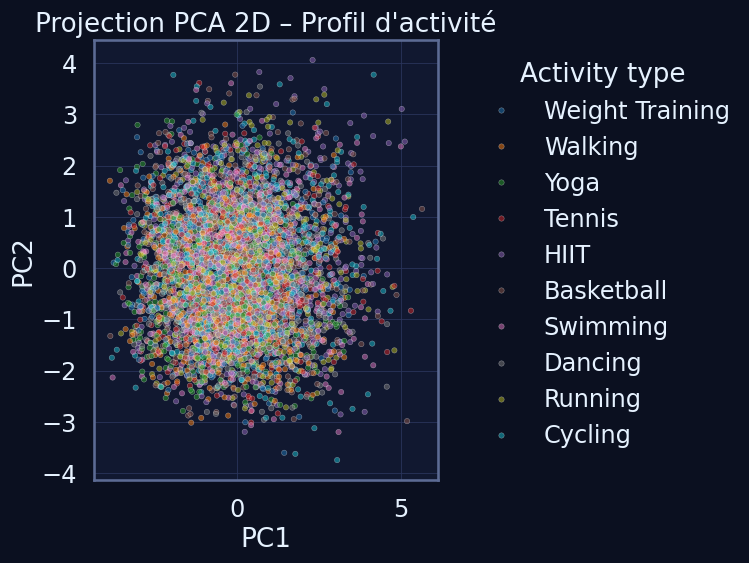

In [26]:
# PCA en 2 composantes pour visualisation
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    X_pca_2d,
    columns=["PC1", "PC2"],
    index=X_num.index  # pour recoller avec df
)

# On ajoute une variable catégorielle pour la coloration (ex. activity_type)
if "activity_type" in df.columns:
    df_pca["activity_type"] = df.loc[df_pca.index, "activity_type"]
else:
    df_pca["activity_type"] = "Unknown"

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca.sample(min(5000, len(df_pca))),  # échantillon pour garder une figure lisible
    x="PC1",
    y="PC2",
    hue="activity_type",
    alpha=0.5,
    s=15,
    palette="tab10"
)
plt.title("Projection PCA 2D – Profil d'activité")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Activity type")
plt.grid(True)
plt.tight_layout()
plt.show()


#### Identification des variables les plus contributrices

In [27]:
# Matrice des contributions (loadings) pour PC1 et PC2
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1_loading", "PC2_loading"],
    index=num_pca_cols
)

# On ajoute une colonne avec la contribution totale (norme L2 des 2 loadings)
loadings["Contribution_abs"] = (loadings["PC1_loading"]**2 + loadings["PC2_loading"]**2) ** 0.5

# Tri des variables les plus contributrices
top_loadings = loadings.sort_values("Contribution_abs", ascending=False).head(15)
display(top_loadings.round(4))


,PC1_loading,PC2_loading,Contribution_abs
avg_heart_rate,0.0049,0.6371,0.6371
age,0.0289,-0.6099,0.6106
weight_kg,0.5865,-0.1061,0.5960
calories_burned,0.3866,0.2881,0.4822
fitness_level,0.4425,0.0001,0.4425
bmi,0.3357,-0.1566,0.3704
duration_minutes,0.1600,0.3031,0.3427
height_cm,0.2962,-0.1033,0.3137
daily_steps,-0.2894,0.0004,0.2894
blood_pressure_systolic,0.0076,0.0203,0.0217


### MCA (Multiple Correspondence Analysis)

La MCA permet d’étudier les variables catégorielles du dataset.  

Elle met en évidence les regroupements de modalités et les similitudes entre profils d’utilisateurs.


#### Encodage + sélection

In [28]:
# Sélection des colonnes catégorielles
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Variables catégorielles :", cat_cols)

# One-hot encoding complet
df_cat = pd.get_dummies(df[cat_cols], drop_first=False)

print("Shape après encodage :", df_cat.shape)


Variables catégorielles : ['date', 'gender', 'activity_type', 'intensity', 'health_condition', 'smoking_status']
Shape après encodage : (687701, 382)


#### Exécution de la MCA

Nous utilisons un algorithme de MCA pour obtenir des axes factoriels 
qui synthétisent les relations entre modalités qualitatives.


In [ ]:
mca = prince.MCA(
    n_components=2,
    n_iter=3,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=42
)

mca_fit = mca.fit(df_cat)
mca_components = mca_fit.transform(df_cat)

mca_components.head()

,0,1
0,-0.047614,0.034224
1,-0.048884,0.003829
2,-0.100702,-0.057266
3,-0.091284,-0.029463
4,-0.115200,-0.089743


#### Visualisation MCA 2D

Cette projection 2D permet d’identifier des regroupements entre profils utilisateurs
en fonction de leurs caractéristiques qualitatives (type d’activité, intensité, état de santé…).


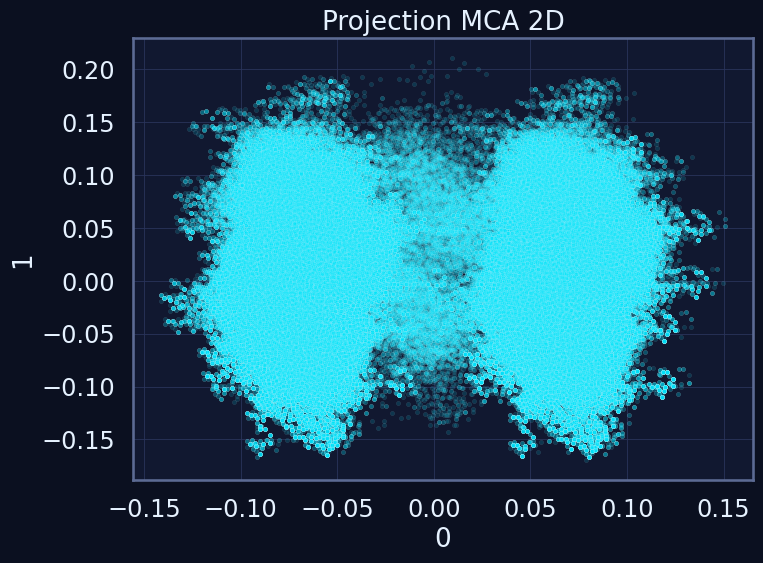

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=mca_components[0],
    y=mca_components[1],
    alpha=0.15,
    s=10
)
plt.title("Projection MCA 2D")
plt.grid(True)
plt.tight_layout()
plt.show()


#### Modalités les plus contributrices

Cette étape met en évidence les modalités catégorielles les plus déterminantes dans la variabilité globale.


In [34]:
# Contributions des modalités (colonnes) aux premières dimensions

mca_contrib = mca_fit.column_contributions_  # DataFrame (modalités x composantes)
display(mca_contrib.head())

# Option : focus sur les modalités les plus contributrices sur les deux 1ères composantes
if mca_contrib.shape[1] >= 2:
    mca_contrib["Contribution_PC1_PC2"] = (
        mca_contrib.iloc[:, 0].abs() + mca_contrib.iloc[:, 1].abs()
    )
    top_modalities = mca_contrib.sort_values(
        "Contribution_PC1_PC2", ascending=False
    ).head(20)

    print("Top 20 modalités les plus contributrices (PC1 + PC2) :")
    display(top_modalities)
else:
    print("Contributions par modalité :")
    display(mca_contrib.sort_values(mca_contrib.columns[0], ascending=False).head(20))


,0,1
date_2024-01-01__False,2.074906e-07,2.856670e-07
date_2024-01-01__True,7.446101e-05,1.025157e-04
date_2024-01-02__False,7.142538e-08,5.283064e-07
date_2024-01-02__True,2.515678e-05,1.860751e-04
date_2024-01-03__False,2.287697e-06,3.480216e-08


Top 20 modalités les plus contributrices (PC1 + PC2) :


,0,1,Contribution_PC1_PC2
gender_M__True,0.228338,1.497775e-04,0.228488
gender_F__True,0.222453,2.471648e-07,0.222453
gender_F__False,0.216083,2.400874e-07,0.216083
gender_M__False,0.215649,1.414539e-04,0.215790
intensity_Medium__True,0.002624,1.551077e-01,0.157732
intensity_Medium__False,0.002618,1.547315e-01,0.157349
intensity_Low__True,0.005635,8.053236e-02,0.086168
intensity_High__True,0.000124,7.532250e-02,0.075447
smoking_status_Never__False,0.004799,4.793429e-02,0.052733
intensity_Low__False,0.002425,3.465761e-02,0.037083


### FAMD (Factor Analysis of Mixed Data)

La FAMD permet d’analyser simultanément des variables numériques et catégorielles afin de
mettre en évidence des profils d’utilisateurs et des dimensions latentes combinant activité,
santé et mode de vie.


#### Préparation des données pour la FAMD

Nous sélectionnons les variables numériques et catégorielles pertinentes, excluons les
identifiants techniques, gérons les valeurs manquantes et, si nécessaire, échantillonnons
le dataset pour garantir des temps de calcul raisonnables.


In [35]:
# Variables numériques et catégorielles
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

num_exclude = ["participant_id"]      # identifiant technique
cat_exclude = ["date"]               # forte cardinalité, peu informative pour la FAMD

famd_num = [c for c in num_cols if c not in num_exclude]
famd_cat = [c for c in cat_cols if c not in cat_exclude]

print("Variables numériques utilisées pour la FAMD :", famd_num)
print("Variables catégorielles utilisées pour la FAMD :", famd_cat)

# Construction du DataFrame mixte
df_famd = df[famd_num + famd_cat].copy()

# Gestion des valeurs manquantes sur les catégorielles
for col in famd_cat:
    df_famd[col] = df_famd[col].fillna("Unknown").astype("category")

# Échantillonnage pour limiter le coût de calcul
max_sample = 50000
if len(df_famd) > max_sample:
    df_famd_sample = df_famd.sample(n=max_sample, random_state=42)
    print(f"✅ Échantillon FAMD : {len(df_famd_sample)} lignes (sur {len(df_famd)})")
else:
    df_famd_sample = df_famd
    print(f"✅ FAMD sur l'ensemble des données : {len(df_famd_sample)} lignes")


Variables numériques utilisées pour la FAMD : ['age', 'height_cm', 'weight_kg', 'duration_minutes', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fitness_level']
Variables catégorielles utilisées pour la FAMD : ['gender', 'activity_type', 'intensity', 'health_condition', 'smoking_status']
✅ Échantillon FAMD : 50000 lignes (sur 687701)


#### FAMD : inertie expliquée

Nous appliquons la FAMD sur le jeu de données mixte (numérique + catégoriel) afin de
quantifier la part de variabilité capturée par les premières dimensions.


In [39]:
famd = prince.FAMD(
    n_components=5,
    n_iter=5,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=42,
)

famd_fit = famd.fit(df_famd_sample)
famd_components = famd_fit.transform(df_famd_sample)

# Inertie expliquée par dimension (via eigenvalues_)
eigenvalues = famd_fit.eigenvalues_

print("Eigenvalues / Inertie FAMD :")
display(eigenvalues)

# Conversion en vecteur numpy (quelle que soit la forme renvoyée)
vals = np.array(eigenvalues, dtype=float).ravel()

# Normalisation pour obtenir la part d'inertie expliquée par dimension
explained = vals / vals.sum()

famd_inertia_df = pd.DataFrame({
    "Dim": [f"Dim{i+1}" for i in range(len(explained))],
    "Explained_Inertia": explained,
    "Cumulative_Inertia": explained.cumsum()
})

print("\nInertie expliquée par dimension (FAMD) :")
display(famd_inertia_df)



Eigenvalues / Inertie FAMD :


array([10.1405001 ,  7.22098579,  6.79261568,  6.68536599,  6.65296976])


Inertie expliquée par dimension (FAMD) :


,Dim,Explained_Inertia,Cumulative_Inertia
0,Dim1,0.270468,0.270468
1,Dim2,0.192598,0.463066
2,Dim3,0.181173,0.644239
3,Dim4,0.178312,0.822552
4,Dim5,0.177448,1.000000


#### Visualisation FAMD 2D

La projection sur les deux premières dimensions permet d’observer la structure globale
des profils utilisateurs, en particulier en fonction du type d’activité.


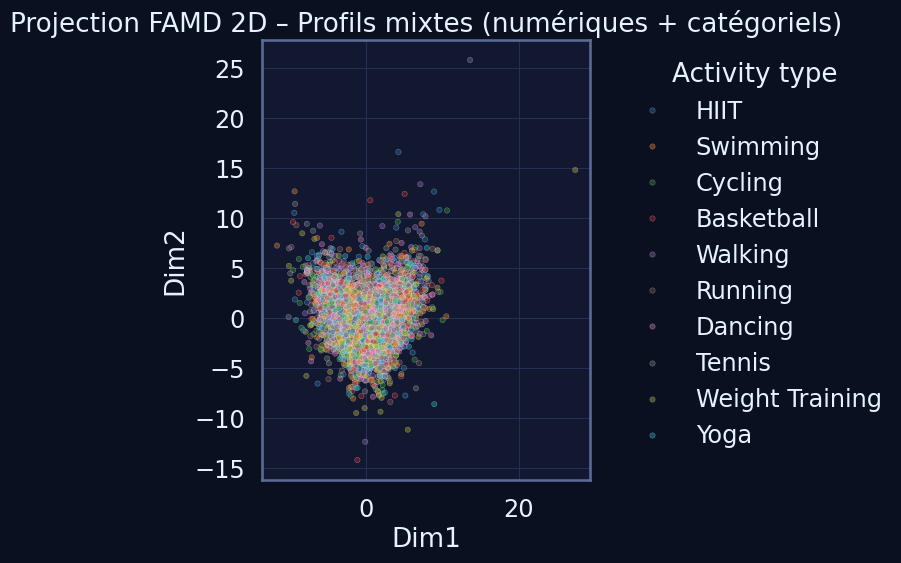

In [40]:
# Récupération des deux premières dimensions
coords_2d = famd_components.iloc[:, :2].copy()
coords_2d.columns = ["Dim1", "Dim2"]

# Ajout du type d'activité pour la coloration
if "activity_type" in df.columns:
    coords_2d["activity_type"] = df.loc[coords_2d.index, "activity_type"]
else:
    coords_2d["activity_type"] = "Unknown"

# Échantillon pour garder une figure lisible
sample_size = min(5000, len(coords_2d))
coords_plot = coords_2d.sample(n=sample_size, random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=coords_plot,
    x="Dim1",
    y="Dim2",
    hue="activity_type",
    alpha=0.4,
    s=15,
    palette="tab10",
)
plt.title("Projection FAMD 2D – Profils mixtes (numériques + catégoriels)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Activity type")
plt.grid(True)
plt.tight_layout()
plt.show()


#### Variables et modalités les plus contributrices

Nous identifions ici les variables (et leurs modalités) contribuant le plus aux deux
premières dimensions de la FAMD, afin de mieux comprendre les axes principaux en termes métier.


In [41]:
# Contributions des colonnes (variables/modalités) aux dimensions
col_contrib = famd_fit.column_contributions_

display(col_contrib.head())

# Score de contribution combinée sur les deux premières dimensions
if col_contrib.shape[1] >= 2:
    col_contrib["Contribution_Dim1_Dim2"] = (
        col_contrib.iloc[:, 0].abs() + col_contrib.iloc[:, 1].abs()
    )

    top_contrib = col_contrib.sort_values(
        "Contribution_Dim1_Dim2", ascending=False
    ).head(25)

    print("Top 25 variables/modalités les plus contributrices (Dim1 + Dim2) :")
    display(top_contrib)
else:
    print("Contributions disponibles (une seule dimension) :")
    display(col_contrib.sort_values(col_contrib.columns[0], ascending=False).head(25))


component,0,1,2,3,4
variable,,,,,
height_cm,8.178761e-06,5.302415e-03,0.004342,5.049916e-04,2.453076e-07
weight_kg,4.055161e-05,2.477755e-03,0.002331,2.952735e-04,5.474099e-05
calories_burned,9.391807e-04,1.746843e-03,0.002366,2.570472e-04,2.856279e-03
hours_sleep,2.379273e-07,7.407721e-08,0.000003,1.348881e-06,6.179270e-07
hydration_level,1.655102e-07,9.747363e-06,0.000003,6.661613e-07,6.139293e-09


Top 25 variables/modalités les plus contributrices (Dim1 + Dim2) :


component,0,1,2,3,4,Contribution_Dim1_Dim2
variable,,,,,,
daily_steps,4.608456e-02,9.388013e-02,1.070888e-01,1.122095e-01,1.128242e-01,1.399647e-01
avg_heart_rate,8.143400e-02,4.189749e-02,3.742225e-02,4.331327e-02,3.821184e-02,1.233315e-01
intensity,4.967733e-02,1.853156e-02,3.974613e-03,2.097828e-03,1.692133e-03,6.820890e-02
age,3.114433e-02,1.941801e-02,2.216665e-02,1.555903e-02,1.625667e-02,5.056234e-02
duration_minutes,2.752710e-03,2.128991e-02,2.141564e-02,2.927698e-02,3.231656e-02,2.404262e-02
gender,7.413579e-05,1.279650e-02,1.045492e-02,2.152050e-03,1.640708e-04,1.287064e-02
height_cm,8.178761e-06,5.302415e-03,4.342449e-03,5.049916e-04,2.453076e-07,5.310594e-03
bmi,1.740172e-04,2.611701e-03,2.225293e-03,2.358789e-04,3.160393e-05,2.785718e-03
calories_burned,9.391807e-04,1.746843e-03,2.366153e-03,2.570472e-04,2.856279e-03,2.686023e-03


## Détection d’anomalies et valeurs extrêmes


### Objectif

Identifier et caractériser les valeurs atypiques présentes dans le dataset FitLife afin de :

- repérer les observations extrêmes susceptibles de biaiser les analyses ;
- distinguer les valeurs réellement rares des erreurs potentielles de mesure ou de génération ;
- préparer les décisions de traitement (conservation, correction, suppression, winsorisation) avant la modélisation.

Nous utilisons pour cela une approche combinée : méthode IQR, visualisation par boxplots et analyse complémentaire via Z-Score.


### Interprétation attendue

Cette section doit permettre de :

- quantifier, pour chaque variable numérique, la proportion de valeurs identifiées comme extrêmes ;
- mettre en évidence les variables les plus concernées par des outliers (ex. `daily_steps`, `calories_burned`, `duration_minutes`, etc.) ;
- illustrer visuellement les distributions les plus problématiques ;
- repérer les cas manifestement incohérents (valeurs négatives, amplitudes physiologiquement impossibles) qui devront faire l’objet d’un traitement spécifique.

L’objectif n’est pas encore de corriger les données, mais de documenter la présence d’anomalies et d’éclairer les choix de nettoyage ultérieur.


### Méthode IQR (Interquartile Range)


In [42]:
# Variables numériques à analyser (on exclut l'identifiant technique)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cols_exclude = ["participant_id"]
num_anom_cols = [c for c in num_cols if c not in cols_exclude]

iqr_stats = []

for col in num_anom_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask_outliers = (df[col] < lower) | (df[col] > upper)
    outlier_pct = mask_outliers.mean() * 100

    iqr_stats.append({
        "variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outliers_pct": outlier_pct,
    })

iqr_df = pd.DataFrame(iqr_stats).sort_values("outliers_pct", ascending=False)
print("🔎 Top variables les plus impactées selon l'IQR :")
display(iqr_df.head(15))


🔎 Top variables les plus impactées selon l'IQR :


,variable,Q1,Q3,IQR,lower_bound,upper_bound,outliers_pct
4,calories_burned,7.80,20.70,12.90,-11.55,40.05,2.536131
13,blood_pressure_diastolic,74.60,85.70,11.10,57.95,102.35,0.888031
6,hours_sleep,6.40,7.70,1.30,4.45,9.65,0.857495
10,bmi,20.10,25.10,5.00,12.60,32.60,0.603024
11,resting_heart_rate,66.50,73.50,7.00,56.00,84.00,0.543550
12,blood_pressure_systolic,113.10,127.00,13.90,92.25,147.85,0.523774
8,daily_steps,7203.00,10027.00,2824.00,2967.00,14263.00,0.449905
5,avg_heart_rate,118.00,144.00,26.00,79.00,183.00,0.271484
2,weight_kg,78.20,110.50,32.30,29.75,158.95,0.248073
1,height_cm,161.70,175.30,13.60,141.30,195.70,0.066890


### Visualisation : boxplots des variables les plus affectées


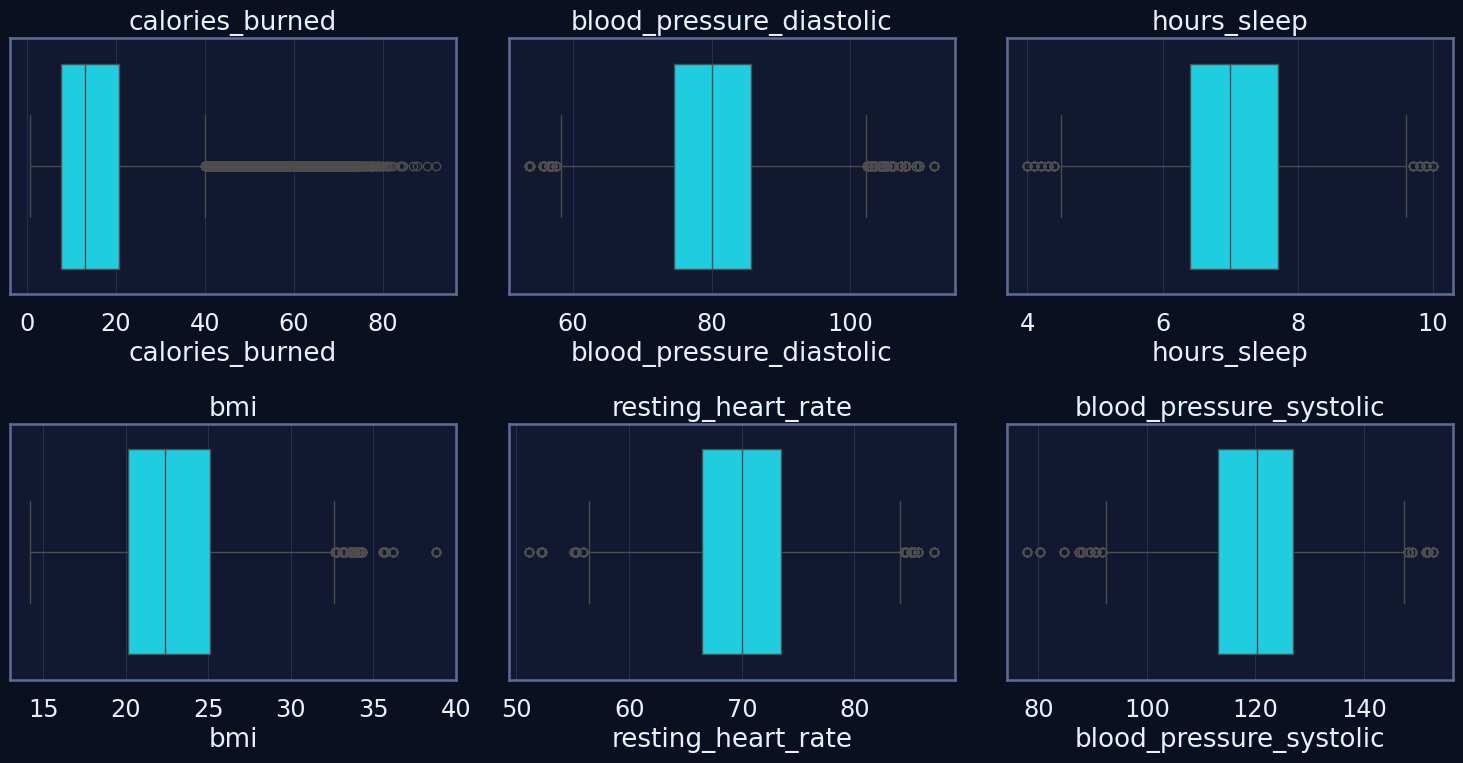

In [43]:
# Sélection des 6 variables les plus touchées par les outliers IQR
top_outlier_vars = iqr_df.head(6)["variable"].tolist()

n = len(top_outlier_vars)
n_cols = 3
n_rows = int(np.ceil(n / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(top_outlier_vars, start=1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.grid(True, axis="x")

plt.tight_layout()
plt.show()


### Z-Score complémentaire (normalisation)

La méthode du Z-Score permet de détecter les valeurs situées très loin de la moyenne
(en général |Z| > 3), après normalisation des variables. Elle offre une vue complémentaire
à l’IQR, notamment pour les distributions proches de la loi normale.


In [45]:
# DataFrame numérique sécurisé (conversion forcée si besoin)
df_num = df[num_anom_cols].apply(pd.to_numeric, errors="coerce")

# Calcul des Z-Scores (avec gestion des NaN)
z_scores = stats.zscore(df_num, nan_policy="omit")

# Si le résultat est un array numpy, on le reconvertit en DataFrame
if isinstance(z_scores, np.ndarray):
    z_df = pd.DataFrame(z_scores, columns=num_anom_cols, index=df.index)
else:
    z_df = z_scores

# Pourcentage d'outliers (|Z| > 3) par variable
z_outlier_pct = (z_df.abs() > 3).sum() / len(df) * 100

z_summary = (
    pd.DataFrame({
        "variable": num_anom_cols,
        "outliers_Z>3_pct": z_outlier_pct.values,
    })
    .sort_values("outliers_Z>3_pct", ascending=False)
)

print("🔎 Top variables les plus impactées selon le Z-Score :")
display(z_summary.head(15))


🔎 Top variables les plus impactées selon le Z-Score :


,variable,outliers_Z>3_pct
4,calories_burned,1.244145
10,bmi,0.404100
13,blood_pressure_diastolic,0.389268
6,hours_sleep,0.331830
12,blood_pressure_systolic,0.327904
11,resting_heart_rate,0.307837
5,avg_heart_rate,0.221172
8,daily_steps,0.168823
2,weight_kg,0.143376
1,height_cm,0.066890
